# Pipeline Comparativo AutoML — CICIoT2023 — Classificação Binária

Este notebook segue a mesma estrutura do pipeline AutoGluon desenvolvido anteriormente, mas permite executar diferentes frameworks AutoML: PyCaret, TPOT, H2O AutoML, Auto-Sklearn, FLAML, LazyPredict, Auto-PyTorch e AutoKeras.

O fluxo mantém as 11 etapas: imports, configurações, funções auxiliares, carregamento dos CSVs, tratamento, criação do rótulo binário, divisão treino/teste, carregamento de modelo salvo, treinamento, avaliação e salvamento dos resultados.

In [70]:
#import sys
#!{sys.executable} -m pip install pycaret

In [71]:
#===================================================
#TESTA O AMBIENTE  PYCARET SE INSTALADO COM SUCESSO
#===================================================
import sys
print(sys.version)

import pycaret
print(pycaret.__version__)

from pycaret.classification import setup, compare_models
print("PyCaret instalado com sucesso!")

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
3.3.2
PyCaret instalado com sucesso!


In [47]:
#===================================================
#TESTA O AMBIENTE  H2O SE INSTALADO COM SUCESSO
#===================================================
import sys
print(sys.version)

import h2o
from h2o.automl import H2OAutoML
print(h2o.__version__)

h2o.init()
print("H2oconda instalado com sucesso!")

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
3.46.0.11
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) Client VM (build 25.431-b10, mixed mode, sharing)
  Starting server from C:\Users\daniel.malenga\.conda\envs\pycaret_cic\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\DANIEL~1.MAL\AppData\Local\Temp\tmp95d9g215
  JVM stdout: C:\Users\DANIEL~1.MAL\AppData\Local\Temp\tmp95d9g215\h2o_daniel_malenga_started_from_python.out
  JVM stderr: C:\Users\DANIEL~1.MAL\AppData\Local\Temp\tmp95d9g215\h2o_daniel_malenga_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,09 secs
H2O_cluster_timezone:,America/Sao_Paulo
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,20 days
H2O_cluster_name:,H2O_from_python_daniel_malenga_um6hou
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,239.4 Mb
H2O_cluster_total_cores:,0
H2O_cluster_allowed_cores:,0
H2O_cluster_status:,"locked, healthy"


H2O instalado com sucesso!


In [1]:
import sys
print(sys.executable)

C:\Users\daniel.malenga\.conda\envs\tpot_cic\python.exe


In [28]:
#===================================================
#TESTA O AMBIENTE  TPOT SE INSTALADO COM SUCESSO
#===================================================
import warnings
warnings.filterwarnings("ignore")

import sys
print(sys.version)

import tpot
print(tpot.__version__)

from tpot import TPOTClassifier

print("TPOT instalado com sucesso!")

3.10.20 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:13:20) [MSC v.1942 64 bit (AMD64)]
0.12.2
TPOT instalado com sucesso!


## 1. Imports

Importa bibliotecas comuns usadas por todo o pipeline.

In [10]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import gc
import json
import time
#import pycaret
#import h2o
#import tpot
import shutil
import joblib
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
#===============================================================
#from pycaret.classification import setup, compare_models, finalize_model, predict_model, save_model, load_model, pull
#from pycaret.classification import setup, compare_models
#from h2o.automl import H2OAutoML

#import autosklearn.classification
#import autosklearn.metrics
#from autosklearn.classification import AutoSklearnClassifier
#==========================================================================================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


warnings.filterwarnings("ignore")

print("1. Imports principais carregados com sucesso.")

1. Imports principais carregados com sucesso.


## 2. Configurações

Define caminhos, rótulos, limites de amostras, tempo de treinamento e o framework a ser executado.

In [11]:
# ============================================================
# 2. CONFIGURAÇÕES
# ============================================================

# Caminho onde estão os arquivos CSV do CICIoT2023.
DATASET_DIR = Path(r"C:\Dataset\CSV")

# Pasta principal onde os resultados serão salvos.
RESULTS_DIR = Path(r"C:\Dataset\Resultados\AutoML_Comparativo")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Nome da coluna original padronizada durante o carregamento.
# Mesmo que o CSV use "label", "Label", "Attack" ou "Class",
# o pipeline copiará esse conteúdo para esta coluna.
LABEL_ORIGEM = "label_original"

# Nome da coluna final usada no treinamento binário.
LABEL_FINAL = "label_binary"

# Classes finais da classificação binária.
CLASSE_BENIGNA = "Benign"
CLASSE_MALICIOSA = "Malicious"
CLASSES_BINARIAS = [CLASSE_BENIGNA, CLASSE_MALICIOSA]

# Divisão treino/teste.
TEST_SIZE = 0.20
RANDOM_STATE = 42

# Leitura dos CSVs em blocos para reduzir uso de memória.
CHUNKSIZE = 200

# Limite de amostras por classe após criação do rótulo binário.
# Use None para não limitar.
MAX_ROWS_PER_CLASS = 200

# Limite opcional de arquivos CSV para testes rápidos.
# Use None para carregar todos os arquivos.
MAX_FILES = 5

# Tempo máximo de treinamento por framework, em segundos.
TIME_LIMIT = 3600

# Controle de modelos salvos.
CARREGAR_MODELO_EXISTENTE = True
TREINAR_SE_NAO_EXISTIR = True
APAGAR_MODELO_ANTERIOR = False
#=======================================================
# Escolha o framework a executar:
# "pycaret", "tpot", "h2o", "autosklearn", "flaml",
# "lazypredict", "autopytorch", "autokeras" ou "todos".
#=======================================================

#########################################################
EXECUTAR_FRAMEWORK = "sklearn"
#########################################################
print("2. Configurações definidas com sucesso.")
print(f"Dataset: {DATASET_DIR}")
print(f"Resultados: {RESULTS_DIR}")


2. Configurações definidas com sucesso.
Dataset: C:\Dataset\CSV
Resultados: C:\Dataset\Resultados\AutoML_Comparativo


## 3. Funções auxiliares

Reúne funções reutilizáveis para detecção de rótulo, limpeza, preparação, métricas, gráficos e salvamento.

In [12]:
# ============================================================
# 3. FUNÇÕES AUXILIARES
# ============================================================

def detectar_coluna_rotulo(columns):
    """
    Detecta automaticamente a coluna de rótulo nos CSVs.
    """
    candidatos = [
        "label", "Label",
        "Attack", "attack",
        "Class", "class",
        "category", "Category",
        "type", "Type",
        "label_multiclass",
        "label_grouped",
        "label_binary"
    ]

    for col in candidatos:
        if col in columns:
            return col

    return None

In [13]:



def converter_para_binario(valor):
    """
    Converte qualquer rótulo do CICIoT2023 para o cenário binário:
    - Benign
    - Malicious
    """
    valor = str(valor).strip().lower()

    if "benign" in valor:
        return CLASSE_BENIGNA

    return CLASSE_MALICIOSA


def remover_colunas_de_rotulo_antigas(df, label_final=LABEL_FINAL, label_origem=LABEL_ORIGEM):
    """
    Remove colunas antigas de rótulo para evitar vazamento de informação.
    """
    colunas_possiveis = [
        "label", "Label",
        "Attack", "attack",
        "Class", "class",
        "category", "Category",
        "type", "Type",
        "label_multiclass",
        "label_grouped",
        "source_file",
        "Source_File",
        "filename",
        "Filename",
        label_origem,
    ]

    colunas_remover = [
        col for col in colunas_possiveis
        if col in df.columns and col != label_final
    ]

    return df.drop(columns=colunas_remover, errors="ignore")


def tratar_dataset(df, label_origem=LABEL_ORIGEM):
    """
    Executa tratamento geral do dataset antes da modelagem.
    """
    df = df.copy()

    # Padroniza nomes de colunas.
    df.columns = df.columns.astype(str).str.strip()

    # Remove colunas duplicadas.
    df = df.loc[:, ~df.columns.duplicated()]

    # Verifica se a coluna de rótulo original existe.
    if label_origem not in df.columns:
        raise ValueError(f"A coluna de rótulo de origem '{label_origem}' não foi encontrada.")

    # Remove linhas sem rótulo.
    df = df.dropna(subset=[label_origem])

    # Substitui infinitos por NaN.
    df = df.replace([np.inf, -np.inf], np.nan)

    # Remove colunas totalmente vazias.
    df = df.dropna(axis=1, how="all")

    # Remove colunas constantes, exceto a coluna de rótulo.
    colunas_constantes = []
    for col in df.columns:
        if col == label_origem:
            continue
        try:
            if df[col].nunique(dropna=False) <= 1:
                colunas_constantes.append(col)
        except TypeError:
            pass

    if colunas_constantes:
        df = df.drop(columns=colunas_constantes, errors="ignore")
        print(f"Colunas constantes removidas: {len(colunas_constantes)}")

    return df


def limpar_para_modelagem(df, label_final=LABEL_FINAL):
    """
    Prepara o DataFrame final para treino/teste.
    """
    df = df.copy()

    if label_final not in df.columns:
        raise ValueError(f"A coluna final de rótulo '{label_final}' não foi encontrada.")

    df = df.dropna(subset=[label_final])
    df = df.replace([np.inf, -np.inf], np.nan)
    df = remover_colunas_de_rotulo_antigas(df, label_final=label_final)
    df = df.dropna(axis=1, how="all")

    return df


def reduzir_por_classe(df, label_col=LABEL_FINAL, max_rows_per_class=MAX_ROWS_PER_CLASS):
    """
    Limita a quantidade de amostras por classe para controlar memória e tempo.
    """
    if max_rows_per_class is None:
        return df

    partes = []
    for classe, grupo in df.groupby(label_col):
        n = min(len(grupo), max_rows_per_class)
        partes.append(grupo.sample(n=n, random_state=RANDOM_STATE))
        print(f"Classe {classe}: {n} amostras selecionadas de {len(grupo)}")

    return pd.concat(partes, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


def preparar_X_y_sklearn(train_data, test_data, label_final=LABEL_FINAL):
    """
    Prepara X/y para frameworks no estilo scikit-learn.
    Faz one-hot encoding para colunas categóricas e imputação de NaN.
    """
    y_train = train_data[label_final].copy()
    y_test = test_data[label_final].copy()

    X_train = train_data.drop(columns=[label_final], errors="ignore").copy()
    X_test = test_data.drop(columns=[label_final], errors="ignore").copy()

    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    # Alinha colunas categóricas entre treino e teste.
    total = pd.concat([X_train, X_test], axis=0, ignore_index=True)
    total = pd.get_dummies(total, dummy_na=True)

    X_train_enc = total.iloc[:len(X_train)].copy()
    X_test_enc = total.iloc[len(X_train):].copy()

    # Imputação numérica.
    imputer = SimpleImputer(strategy="median")
    X_train_enc = pd.DataFrame(
        imputer.fit_transform(X_train_enc),
        columns=X_train_enc.columns,
        index=X_train.index
    )
    X_test_enc = pd.DataFrame(
        imputer.transform(X_test_enc),
        columns=X_test_enc.columns,
        index=X_test.index
    )

    return X_train_enc, X_test_enc, y_train, y_test


def obter_score_positivo(y_proba, classe_positiva=CLASSE_MALICIOSA):
    """
    Extrai a probabilidade da classe positiva Malicious, quando disponível.
    """
    if y_proba is None:
        return None

    if isinstance(y_proba, pd.DataFrame):
        if classe_positiva in y_proba.columns:
            return y_proba[classe_positiva].values
        if 1 in y_proba.columns:
            return y_proba[1].values
        if y_proba.shape[1] >= 2:
            return y_proba.iloc[:, 1].values

    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 2 and y_proba.shape[1] >= 2:
        return y_proba[:, 1]

    if y_proba.ndim == 1:
        return y_proba

    return None


def calcular_metricas(y_test, y_pred, y_score=None):
    """
    Calcula métricas principais para classificação binária.
    """
    labels = CLASSES_BINARIAS
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

    metricas = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=CLASSE_MALICIOSA, zero_division=0),
        "Recall / Sensibilidade": recall_score(y_test, y_pred, pos_label=CLASSE_MALICIOSA, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, pos_label=CLASSE_MALICIOSA, zero_division=0),
        "Specificity": specificity,
        "MCC": matthews_corrcoef(y_test, y_pred),
        "False Positive Rate": fpr,
        "False Negative Rate": fnr,
    }

    if y_score is not None:
        y_bin = pd.Series(y_test).map({CLASSE_BENIGNA: 0, CLASSE_MALICIOSA: 1}).values
        try:
            metricas["ROC-AUC"] = roc_auc_score(y_bin, y_score)
        except Exception:
            metricas["ROC-AUC"] = np.nan
        try:
            metricas["Average Precision"] = average_precision_score(y_bin, y_score)
        except Exception:
            metricas["Average Precision"] = np.nan
    else:
        metricas["ROC-AUC"] = np.nan
        metricas["Average Precision"] = np.nan

    return metricas, cm


def salvar_tabela_png(df, caminho_png, titulo, figsize=(12, 4), fontsize=9):
    """
    Salva um DataFrame como imagem PNG.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    tabela = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(fontsize)
    tabela.scale(1, 1.3)

    plt.title(titulo, fontsize=12)
    plt.tight_layout()
    plt.savefig(caminho_png, dpi=300, bbox_inches="tight")
    plt.show()


def salvar_matriz_confusao_png(cm, caminho_png, titulo):
    """
    Salva matriz de confusão em PNG.
    """

    fig, ax = plt.subplots(figsize=(6, 5))

    # Matriz com escala de cor azul
    im = ax.imshow(cm, cmap="Blues")

    ax.set_title(titulo)
    ax.set_xlabel("Classe predita")
    ax.set_ylabel("Classe real")

    ax.set_xticks(np.arange(len(CLASSES_BINARIAS)))
    ax.set_yticks(np.arange(len(CLASSES_BINARIAS)))

    ax.set_xticklabels(CLASSES_BINARIAS)
    ax.set_yticklabels(CLASSES_BINARIAS)

    # Escrever os valores dentro da matriz
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center",
                va="center",
                color="black"
            )

    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig(caminho_png, dpi=300, bbox_inches="tight")
    plt.show()


def avaliar_e_salvar(nome_modelo, y_test, y_pred, y_proba=None, leaderboard=None, extra_info=None):
    """
    Avalia as predições e salva métricas, relatório, matriz de confusão e leaderboard.
    """
    modelo_dir = RESULTS_DIR / nome_modelo
    modelo_dir.mkdir(parents=True, exist_ok=True)

    y_score = obter_score_positivo(y_proba)
    metricas, cm = calcular_metricas(y_test, y_pred, y_score)

    metricas_df = pd.DataFrame({
        "Métrica": list(metricas.keys()),
        "Valor": list(metricas.values())
    })

    print("\n====================================================")
    print(f"RESULTADOS - {nome_modelo}")
    print("====================================================")
    print(metricas_df)

    metricas_csv = modelo_dir / f"metricas_{nome_modelo}.csv"
    metricas_png = modelo_dir / f"metricas_{nome_modelo}.png"
    metricas_df.to_csv(metricas_csv, index=False)
    salvar_tabela_png(metricas_df, metricas_png, f"Métricas - {nome_modelo}", figsize=(10, 5))

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=CLASSES_BINARIAS,
        target_names=CLASSES_BINARIAS,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_csv = modelo_dir / f"classification_report_{nome_modelo}.csv"
    report_png = modelo_dir / f"classification_report_{nome_modelo}.png"
    report_df.to_csv(report_csv)
    salvar_tabela_png(report_df.round(4).reset_index(), report_png, f"Classification Report - {nome_modelo}", figsize=(12, 5), fontsize=8)

    cm_csv = modelo_dir / f"matriz_confusao_{nome_modelo}.csv"
    cm_png = modelo_dir / f"matriz_confusao_{nome_modelo}.png"
    cm_df = pd.DataFrame(cm, index=[f"Real_{c}" for c in CLASSES_BINARIAS], columns=[f"Pred_{c}" for c in CLASSES_BINARIAS])
    cm_df.to_csv(cm_csv)
    salvar_matriz_confusao_png(cm, cm_png, f"Matriz de Confusão - {nome_modelo}")

    inferencias_df = pd.DataFrame({
        "y_real": list(y_test),
        "y_pred": list(y_pred)
    })
    if y_score is not None:
        inferencias_df["score_malicious"] = y_score
    inferencias_df.to_csv(modelo_dir / f"inferencias_{nome_modelo}.csv", index=False)

    if leaderboard is not None:
        leaderboard_df = pd.DataFrame(leaderboard)
        leaderboard_csv = modelo_dir / f"leaderboard_{nome_modelo}.csv"
        leaderboard_png = modelo_dir / f"leaderboard_{nome_modelo}.png"
        leaderboard_df.to_csv(leaderboard_csv, index=False)
        salvar_tabela_png(leaderboard_df.head(15), leaderboard_png, f"Leaderboard - {nome_modelo}", figsize=(14, 6), fontsize=7)

    if extra_info is not None:
        with open(modelo_dir / f"info_{nome_modelo}.json", "w", encoding="utf-8") as f:
            json.dump(extra_info, f, indent=4, ensure_ascii=False, default=str)

    print(f"\nResultados salvos em: {modelo_dir}")
    return metricas_df

print("3. Funções auxiliares criadas com sucesso.")

3. Funções auxiliares criadas com sucesso.


## 4. Carregar CSVs

Localiza e carrega os arquivos CSV em blocos, copiando a coluna de rótulo detectada para `label_original`.

In [14]:
# ============================================================
# 4. CARREGAR CSVs - CORRIGIDO
# ============================================================

def extrair_rotulo_do_nome_arquivo(nome_arquivo):
    """
    Extrai o rótulo original a partir do nome do arquivo.
    Exemplo:
    Backdoor_Malware.pcap.csv -> Backdoor_Malware
    BenignTraffic.pcap.csv -> BenignTraffic
    """
    nome = nome_arquivo.replace(".csv", "")
    nome = nome.replace(".pcap", "")
    return nome


def carregar_csvs():
    """
    Localiza e carrega os CSVs do CICIoT2023.
    Se o arquivo não possuir coluna de rótulo, o rótulo será obtido pelo nome do arquivo.
    """

    if not DATASET_DIR.exists():
        raise FileNotFoundError(f"Diretório não encontrado: {DATASET_DIR}")

    csv_files = sorted(DATASET_DIR.glob("*.csv"))
    csv_files = [f for f in csv_files if "merged" not in f.name.lower()]

    if MAX_FILES is not None:
        csv_files = csv_files[:MAX_FILES]

    if not csv_files:
        raise FileNotFoundError(f"Nenhum CSV encontrado em: {DATASET_DIR}")

    print(f"Arquivos CSV encontrados: {len(csv_files)}")

    partes = []

    for idx, arquivo in enumerate(csv_files, start=1):
        print(f"[{idx}/{len(csv_files)}] Lendo: {arquivo.name}")

        rotulo_nome_arquivo = extrair_rotulo_do_nome_arquivo(arquivo.name)

        try:
            for chunk in pd.read_csv(arquivo, chunksize=CHUNKSIZE, low_memory=False):
                chunk.columns = chunk.columns.astype(str).str.strip()

                coluna_rotulo = detectar_coluna_rotulo(chunk.columns)

                if coluna_rotulo is not None:
                    chunk[LABEL_ORIGEM] = chunk[coluna_rotulo]
                else:
                    chunk[LABEL_ORIGEM] = rotulo_nome_arquivo

                chunk["source_file"] = arquivo.name

                partes.append(chunk)

        except Exception as e:
            print(f"Erro ao ler {arquivo.name}: {e}")

    if not partes:
        raise ValueError("Nenhum dado foi carregado. Verifique os CSVs e a coluna de rótulo.")

    df = pd.concat(partes, ignore_index=True)

    print(f"Dataset carregado: {df.shape}")
    print("\nExemplo de rótulos carregados:")
    print(df[LABEL_ORIGEM].value_counts().head(20))

    return df


# Execute:
df_raw = carregar_csvs()

Arquivos CSV encontrados: 5
[1/5] Lendo: Backdoor_Malware.pcap.csv
[2/5] Lendo: BenignTraffic.pcap.csv
[3/5] Lendo: BenignTraffic1.pcap.csv
[4/5] Lendo: BenignTraffic2.pcap.csv
[5/5] Lendo: BenignTraffic3.pcap.csv
Dataset carregado: (1101409, 41)

Exemplo de rótulos carregados:
label_original
BenignTraffic       362361
BenignTraffic2      310413
BenignTraffic1      295585
BenignTraffic3      129832
Backdoor_Malware      3218
Name: count, dtype: int64


## 5. Tratar dataset

Aplica limpeza inicial: remove duplicadas, infinitos, colunas vazias e linhas sem rótulo.

In [15]:
# ============================================================
# 5. TRATAR DATASET
# ============================================================

def etapa_tratar_dataset(df_raw):
    """
    Aplica tratamento inicial no dataset carregado.
    """
    df = tratar_dataset(df_raw, label_origem=LABEL_ORIGEM)
    print(f"Dataset após tratamento inicial: {df.shape}")
    return df

# Execute:
df_tratado = etapa_tratar_dataset(df_raw)

Colunas constantes removidas: 2
Dataset após tratamento inicial: (1101409, 39)


## 6. Criar rótulo binário Benign/Malicious

Converte os rótulos originais do CICIoT2023 para `Benign` ou `Malicious`.

In [16]:
# ============================================================
# 6. CRIAR RÓTULO BINÁRIO BENIGN/MALICIOUS
# ============================================================

def etapa_criar_rotulo_binario(df_tratado):
    """
    Cria a coluna label_binary com as classes Benign e Malicious.
    """
    df = df_tratado.copy()
    df[LABEL_FINAL] = df[LABEL_ORIGEM].apply(converter_para_binario)
    df = limpar_para_modelagem(df, label_final=LABEL_FINAL)
    df = reduzir_por_classe(df, label_col=LABEL_FINAL, max_rows_per_class=MAX_ROWS_PER_CLASS)

    print("Distribuição das classes binárias:")
    print(df[LABEL_FINAL].value_counts())
    print(f"Dataset final para modelagem: {df.shape}")

    return df

# Execute:
df_modelagem = etapa_criar_rotulo_binario(df_tratado)

Classe Benign: 200 amostras selecionadas de 1098191
Classe Malicious: 200 amostras selecionadas de 3218
Distribuição das classes binárias:
label_binary
Malicious    200
Benign       200
Name: count, dtype: int64
Dataset final para modelagem: (400, 38)


## 7. Dividir em train_data e test_data

Divide o dataset em treino e teste, mantendo estratificação por classe.

In [17]:
# ============================================================
# 7. DIVIDIR EM train_data E test_data
# ============================================================

def etapa_dividir_treino_teste(df_modelagem):
    """
    Divide o dataset em treino e teste com estratificação por classe.
    """
    train_data, test_data = train_test_split(
        df_modelagem,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=df_modelagem[LABEL_FINAL]
    )

    train_data = train_data.reset_index(drop=True)
    test_data = test_data.reset_index(drop=True)

    print(f"train_data: {train_data.shape}")
    print(f"test_data : {test_data.shape}")
    print("\nClasses no treino:")
    print(train_data[LABEL_FINAL].value_counts())
    print("\nClasses no teste:")
    print(test_data[LABEL_FINAL].value_counts())

    return train_data, test_data

# Execute:
train_data, test_data = etapa_dividir_treino_teste(df_modelagem)

train_data: (320, 38)
test_data : (80, 38)

Classes no treino:
label_binary
Malicious    160
Benign       160
Name: count, dtype: int64

Classes no teste:
label_binary
Benign       40
Malicious    40
Name: count, dtype: int64


In [18]:
EXECUTAR_FRAMEWORK = "sklearn"

In [20]:
print("Framework selecionado:", EXECUTAR_FRAMEWORK)

Framework selecionado: sklearn


## 8 a 11. Modelos AutoML, avaliação e salvamento

Implementa uma função para cada framework AutoML, mantendo a lógica de carregar modelo, treinar, avaliar e salvar resultados.

In [27]:
# ============================================================
# 8-11. MODELOS AutoML
# ============================================================

# Cada função abaixo segue a mesma lógica:
# 8. Carregar modelo já treinado, se existir.
# 9. Treinar modelo, se não existir modelo salvo.
# 10. Avaliar no test_data.
# 11. Salvar métricas, leaderboard e matriz de confusão.

#============================================================================================================
def executar_pycaret(train_data, test_data):
    """
    Pipeline AutoML com PyCaret para classificação binária.
    """
    nome = "pycaret"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)
    modelo_path = modelo_dir / "modelo_pycaret"

    if APAGAR_MODELO_ANTERIOR and modelo_dir.exists():
        shutil.rmtree(modelo_dir)
        modelo_dir.mkdir(parents=True, exist_ok=True)

    from pycaret.classification import setup, compare_models, finalize_model, predict_model, save_model, load_model, pull
    from pycaret.classification import add_metric

    setup(
        data=train_data,
        target=LABEL_FINAL,
        session_id=RANDOM_STATE,
        verbose=False,
        html=False,
        fold=5,
        n_jobs=-1,
    )

    try:
        add_metric("balanced_accuracy", "Balanced Accuracy", balanced_accuracy_score, greater_is_better=True)
        sort_metric = "Balanced Accuracy"
    except Exception:
        sort_metric = "F1"

    pkl_path = Path(str(modelo_path) + ".pkl")
    if CARREGAR_MODELO_EXISTENTE and pkl_path.exists():
        print("Carregando modelo PyCaret existente...")
        modelo = load_model(str(modelo_path))
    else:
        if not TREINAR_SE_NAO_EXISTIR:
            raise FileNotFoundError(f"Modelo PyCaret não encontrado: {pkl_path}")

        print("Treinando modelo PyCaret...")
        best = compare_models(sort=sort_metric, turbo=True)
        leaderboard = pull()
        modelo = finalize_model(best)
        save_model(modelo, str(modelo_path))
        leaderboard.to_csv(modelo_dir / "leaderboard_pycaret_treino.csv", index=False)

    X_test = test_data.drop(columns=[LABEL_FINAL], errors="ignore")
    pred_df = predict_model(modelo, data=X_test)

    pred_col = "prediction_label" if "prediction_label" in pred_df.columns else "Label"
    score_col = "prediction_score" if "prediction_score" in pred_df.columns else None

    y_pred = pred_df[pred_col]
    y_proba = pred_df[score_col] if score_col and score_col in pred_df.columns else None

    leaderboard_final = None
    try:
        leaderboard_final = pull()
    except Exception:
        pass

    return avaliar_e_salvar(nome, test_data[LABEL_FINAL], y_pred, y_proba, leaderboard=leaderboard_final)
    
#============================================================================================================

def executar_tpot(train_data, test_data):
    """
    Pipeline AutoML com TPOT para classificação binária.
    """
    nome = "tpot"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)
    modelo_path = modelo_dir / "modelo_tpot.pkl"

    if APAGAR_MODELO_ANTERIOR and modelo_path.exists():
        modelo_path.unlink()

    X_train, X_test, y_train, y_test = preparar_X_y_sklearn(train_data, test_data)

    if CARREGAR_MODELO_EXISTENTE and modelo_path.exists():
        print("Carregando modelo TPOT existente...")
        modelo = joblib.load(modelo_path)
    else:
        if not TREINAR_SE_NAO_EXISTIR:
            raise FileNotFoundError(f"Modelo TPOT não encontrado: {modelo_path}")

        print("Treinando modelo TPOT...")
        
        from tpot import TPOTClassifier

        modelo = TPOTClassifier(
            generations=5,
            population_size=20,
            cv=3,
            scoring="accuracy",
            verbosity=2,
            random_state=42,
            n_jobs=1,
            max_time_mins=10,
            periodic_checkpoint_folder=None
        )
        modelo.fit(X_train, y_train)
        joblib.dump(modelo.fitted_pipeline_, modelo_path)
        modelo.export(str(modelo_dir / "pipeline_tpot_exportado.py"))

    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test) if hasattr(modelo, "predict_proba") else None

    leaderboard = None
    if hasattr(modelo, "evaluated_individuals_"):
        leaderboard = pd.DataFrame(modelo.evaluated_individuals_).transpose().reset_index().rename(columns={"index": "pipeline"})

    return avaliar_e_salvar(nome, y_test, y_pred, y_proba, leaderboard=leaderboard)
    
#============================================================================================================

def executar_h2o(train_data, test_data):
    """
    Pipeline AutoML com H2O AutoML para classificação binária.
    """
    nome = "h2o"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)
    model_path_txt = modelo_dir / "h2o_model_path.txt"

    import h2o
    from h2o.automl import H2OAutoML

    h2o.init()

    features = [c for c in train_data.columns if c != LABEL_FINAL]

    # H2O trabalha melhor com a coluna alvo como fator em classificação.
    train_h2o = h2o.H2OFrame(train_data)
    test_h2o = h2o.H2OFrame(test_data)
    train_h2o[LABEL_FINAL] = train_h2o[LABEL_FINAL].asfactor()
    test_h2o[LABEL_FINAL] = test_h2o[LABEL_FINAL].asfactor()

    if CARREGAR_MODELO_EXISTENTE and model_path_txt.exists():
        print("Carregando modelo H2O existente...")
        saved_path = model_path_txt.read_text(encoding="utf-8").strip()
        modelo = h2o.load_model(saved_path)
        leaderboard = None
    else:
        if not TREINAR_SE_NAO_EXISTIR:
            raise FileNotFoundError("Modelo H2O não encontrado.")

        print("Treinando modelo H2O AutoML...")
        aml = H2OAutoML(
            max_runtime_secs=TIME_LIMIT,
            seed=RANDOM_STATE,
            sort_metric="AUCPR",
            balance_classes=False,
        )
        aml.train(x=features, y=LABEL_FINAL, training_frame=train_h2o)
        modelo = aml.leader
        saved_path = h2o.save_model(modelo, path=str(modelo_dir), force=True)
        model_path_txt.write_text(saved_path, encoding="utf-8")
        leaderboard = aml.leaderboard.as_data_frame()

    pred_h2o = modelo.predict(test_h2o).as_data_frame()
    y_pred = pred_h2o["predict"].astype(str)

    y_proba = None
    if CLASSE_MALICIOSA in pred_h2o.columns:
        y_proba = pred_h2o[CLASSE_MALICIOSA]

    return avaliar_e_salvar(nome, test_data[LABEL_FINAL], y_pred, y_proba, leaderboard=leaderboard)
    
#============================================================================================================

def executar_sklearn(train_data, test_data):
    """
    Pipeline AutoML com Auto-Sklearn para classificação binária.
    Observação: Auto-Sklearn é mais indicado em Linux/WSL/Conda.
    """
    nome = "sklearn"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)
    modelo_path = modelo_dir / "modelo_sklearn.pkl"

    X_train, X_test, y_train, y_test = preparar_X_y_sklearn(train_data, test_data)

    if CARREGAR_MODELO_EXISTENTE and modelo_path.exists():
        print("Carregando modelo Auto-Sklearn existente...")
        modelo = joblib.load(modelo_path)
    else:
        if not TREINAR_SE_NAO_EXISTIR:
            raise FileNotFoundError(f"Modelo Sklearn não encontrado: {modelo_path}")

        print("Treinando modelo Sklearn...")
        
    
        from sklearn.ensemble import RandomForestClassifier

        modelo = RandomForestClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        )
        modelo.fit(X_train, y_train)
        joblib.dump(modelo, modelo_path)
      
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test) if hasattr(modelo, "predict_proba") else None

    leaderboard = None
    try:
        leaderboard = modelo.leaderboard()
    except Exception:
        try:
            leaderboard = pd.DataFrame([{"statistics": modelo.sprint_statistics()}])
        except Exception:
            pass

    return avaliar_e_salvar(nome, y_test, y_pred, y_proba, leaderboard=leaderboard)
    
#============================================================================================================

def executar_flaml(train_data, test_data):
    """
    Pipeline AutoML com FLAML para classificação binária.
    """
    nome = "flaml"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)
    modelo_path = modelo_dir / "modelo_flaml.pkl"

    X_train, X_test, y_train, y_test = preparar_X_y_sklearn(train_data, test_data)

    if CARREGAR_MODELO_EXISTENTE and modelo_path.exists():
        print("Carregando modelo FLAML existente...")
        modelo = joblib.load(modelo_path)
    else:
        if not TREINAR_SE_NAO_EXISTIR:
            raise FileNotFoundError(f"Modelo FLAML não encontrado: {modelo_path}")

        print("Treinando modelo FLAML...")
        from flaml import AutoML

        modelo = AutoML()
        modelo.fit(
            X_train=X_train,
            y_train=y_train,
            task="classification",
            time_budget=TIME_LIMIT,
            metric="macro_f1",
            log_file_name=str(modelo_dir / "flaml.log"),
            seed=RANDOM_STATE,
        )
        joblib.dump(modelo, modelo_path)

    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test) if hasattr(modelo, "predict_proba") else None

    leaderboard = pd.DataFrame([{
        "best_estimator": getattr(modelo, "best_estimator", None),
        "best_config": getattr(modelo, "best_config", None),
        "best_loss": getattr(modelo, "best_loss", None),
    }])

    return avaliar_e_salvar(nome, y_test, y_pred, y_proba, leaderboard=leaderboard)

#============================================================================================================

def executar_lazypredict(train_data, test_data):
    """
    Pipeline com LazyPredict.
    Observação: LazyPredict é mais adequado para comparar vários modelos rapidamente;
    ele não é a melhor opção para persistir um único modelo final.
    """
    nome = "lazypredict"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)

    X_train, X_test, y_train, y_test = preparar_X_y_sklearn(train_data, test_data)

    print("Executando LazyPredict...")
    from lazypredict.Supervised import LazyClassifier

    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
    modelos, predicoes = clf.fit(X_train, X_test, y_train, y_test)

    modelos = modelos.reset_index().rename(columns={"index": "model"})
    best_model_name = modelos.iloc[0]["model"]

    if best_model_name in predicoes.columns:
        y_pred = predicoes[best_model_name]
    else:
        # Fallback: usa a primeira coluna de predições.
        y_pred = predicoes.iloc[:, 0]

    predicoes.to_csv(modelo_dir / "predicoes_lazypredict_todos_modelos.csv", index=False)

    return avaliar_e_salvar(nome, y_test, y_pred, y_proba=None, leaderboard=modelos, extra_info={"best_model": best_model_name})

#============================================================================================================

def executar_autopytorch(train_data, test_data):
    """
    Pipeline AutoML com Auto-PyTorch para classificação binária.
    Observação: recomendado executar em Linux/WSL/Conda com PyTorch instalado.
    """
    nome = "autopytorch"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)
    modelo_path = modelo_dir / "modelo_autopytorch.pkl"

    X_train, X_test, y_train, y_test = preparar_X_y_sklearn(train_data, test_data)

    if CARREGAR_MODELO_EXISTENTE and modelo_path.exists():
        print("Carregando modelo Auto-PyTorch existente...")
        with open(modelo_path, "rb") as f:
            api = pickle.load(f)
    else:
        if not TREINAR_SE_NAO_EXISTIR:
            raise FileNotFoundError(f"Modelo Auto-PyTorch não encontrado: {modelo_path}")

        print("Treinando modelo Auto-PyTorch...")
        os.environ["JOBLIB_TEMP_FOLDER"] = str(modelo_dir / "tmp")
        os.environ["OMP_NUM_THREADS"] = "1"
        os.environ["OPENBLAS_NUM_THREADS"] = "1"
        os.environ["MKL_NUM_THREADS"] = "1"

        from autoPyTorch.api.tabular_classification import TabularClassificationTask

        api = TabularClassificationTask(
            temporary_directory=str(modelo_dir / "tmp"),
            output_directory=str(modelo_dir / "out"),
            delete_tmp_folder_after_terminate=False,
            delete_output_folder_after_terminate=False,
            seed=RANDOM_STATE,
        )

        api.search(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test.copy(),
            y_test=y_test.copy(),
            dataset_name="CICIoT2023_Binario",
            optimize_metric="balanced_accuracy",
            total_walltime_limit=TIME_LIMIT,
            func_eval_time_limit_secs=max(60, min(600, TIME_LIMIT // 3)),
        )

        try:
            api.refit(X_train=X_train, y_train=y_train)
        except Exception:
            pass

        with open(modelo_path, "wb") as f:
            pickle.dump(api, f)

    y_pred = api.predict(X_test)
    try:
        y_proba = api.predict_proba(X_test)
    except Exception:
        y_proba = None

    leaderboard = None
    try:
        leaderboard = pd.DataFrame([{"statistics": api.sprint_statistics()}])
    except Exception:
        pass

    return avaliar_e_salvar(nome, y_test, y_pred, y_proba, leaderboard=leaderboard)
    
#============================================================================================================

def executar_autokeras(train_data, test_data):
    """
    Pipeline AutoML com AutoKeras StructuredDataClassifier.
    """
    nome = "autokeras"
    modelo_dir = RESULTS_DIR / nome
    modelo_dir.mkdir(parents=True, exist_ok=True)
    modelo_path = modelo_dir / "modelo_autokeras.keras"

    X_train, X_test, y_train, y_test = preparar_X_y_sklearn(train_data, test_data)

    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)
    y_test_enc = label_encoder.transform(y_test)
    joblib.dump(label_encoder, modelo_dir / "label_encoder.pkl")

    if CARREGAR_MODELO_EXISTENTE and modelo_path.exists():
        print("Carregando modelo AutoKeras existente...")
        import tensorflow as tf
        modelo = tf.keras.models.load_model(modelo_path)
    else:
        if not TREINAR_SE_NAO_EXISTIR:
            raise FileNotFoundError(f"Modelo AutoKeras não encontrado: {modelo_path}")

        print("Treinando modelo AutoKeras...")
        import autokeras as ak

        modelo_ak = ak.StructuredDataClassifier(
            max_trials=10,
            overwrite=True,
            seed=RANDOM_STATE,
            objective="val_accuracy",
        )

        modelo_ak.fit(
            X_train,
            y_train_enc,
            epochs=20,
            validation_split=0.2,
            verbose=1,
        )

        modelo = modelo_ak.export_model()
        modelo.save(modelo_path)

    y_score = modelo.predict(X_test).ravel()
    y_pred_enc = (y_score >= 0.5).astype(int)
    y_pred = label_encoder.inverse_transform(y_pred_enc)

    return avaliar_e_salvar(nome, y_test, y_pred, y_score, leaderboard=None)
#============================================================================================================

def executar_framework(nome_framework, train_data, test_data):
    """
    Executa o framework escolhido.
    """
    nome_framework = nome_framework.lower().strip()

    mapa = {
        "pycaret": executar_pycaret,
        "tpot": executar_tpot,
        "h2o": executar_h2o,
        #"auto-sklearn": executar_autosklearn,
        "flaml": executar_flaml,
        "lazypredict": executar_lazypredict,
        "lazy": executar_lazypredict,
        "autopytorch": executar_autopytorch,
        "auto-pytorch": executar_autopytorch,
        "autokeras": executar_autokeras,
        "auto-keras": executar_autokeras,
        "sklearn": executar_sklearn,
        
    }

    if nome_framework == "todos":
        resultados = {}
        for nome, func in mapa.items():
            # Evita repetir aliases.
            if nome in ["auto-sklearn", "lazy", "auto-pytorch", "auto-keras"]:
                continue
            print("\n" + "=" * 70)
            print(f"EXECUTANDO FRAMEWORK: {nome}")
            print("=" * 70)
            try:
                resultados[nome] = func(train_data, test_data)
            except Exception as e:
                print(f"Erro ao executar {nome}: {e}")
        return resultados

    if nome_framework not in mapa:
        raise ValueError(f"Framework inválido: {nome_framework}")

    return mapa[nome_framework](train_data, test_data)

print("8-11. Funções dos modelos AutoML criadas com sucesso.")

8-11. Funções dos modelos AutoML criadas com sucesso.


## Execução completa do pipeline

Bloco final para executar o pipeline. Descomente as linhas para iniciar o treinamento.

Arquivos CSV encontrados: 5
[1/5] Lendo: Backdoor_Malware.pcap.csv
[2/5] Lendo: BenignTraffic.pcap.csv
[3/5] Lendo: BenignTraffic1.pcap.csv
[4/5] Lendo: BenignTraffic2.pcap.csv
[5/5] Lendo: BenignTraffic3.pcap.csv
Dataset carregado: (1101409, 41)

Exemplo de rótulos carregados:
label_original
BenignTraffic       362361
BenignTraffic2      310413
BenignTraffic1      295585
BenignTraffic3      129832
Backdoor_Malware      3218
Name: count, dtype: int64
Colunas constantes removidas: 2
Dataset após tratamento inicial: (1101409, 39)
Classe Benign: 200 amostras selecionadas de 1098191
Classe Malicious: 200 amostras selecionadas de 3218
Distribuição das classes binárias:
label_binary
Malicious    200
Benign       200
Name: count, dtype: int64
Dataset final para modelagem: (400, 38)
train_data: (320, 38)
test_data : (80, 38)

Classes no treino:
label_binary
Malicious    160
Benign       160
Name: count, dtype: int64

Classes no teste:
label_binary
Benign       40
Malicious    40
Name: count, d

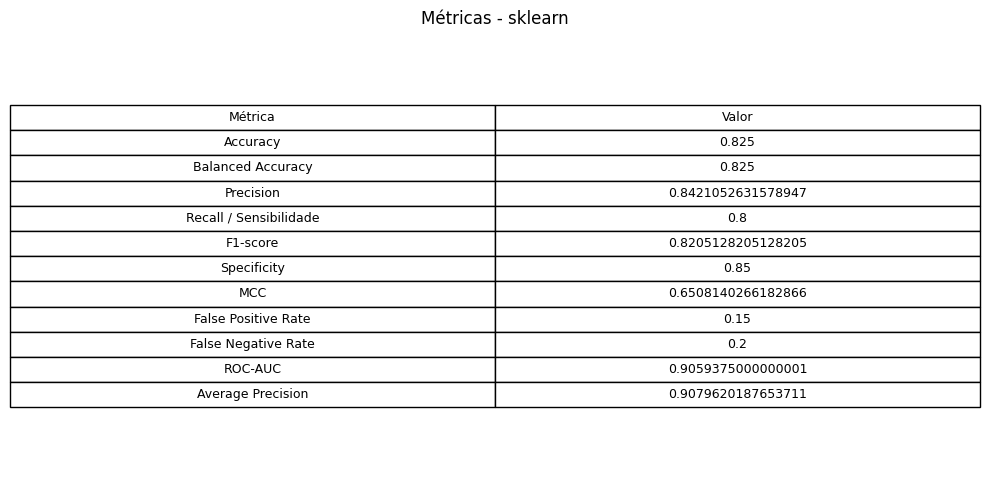

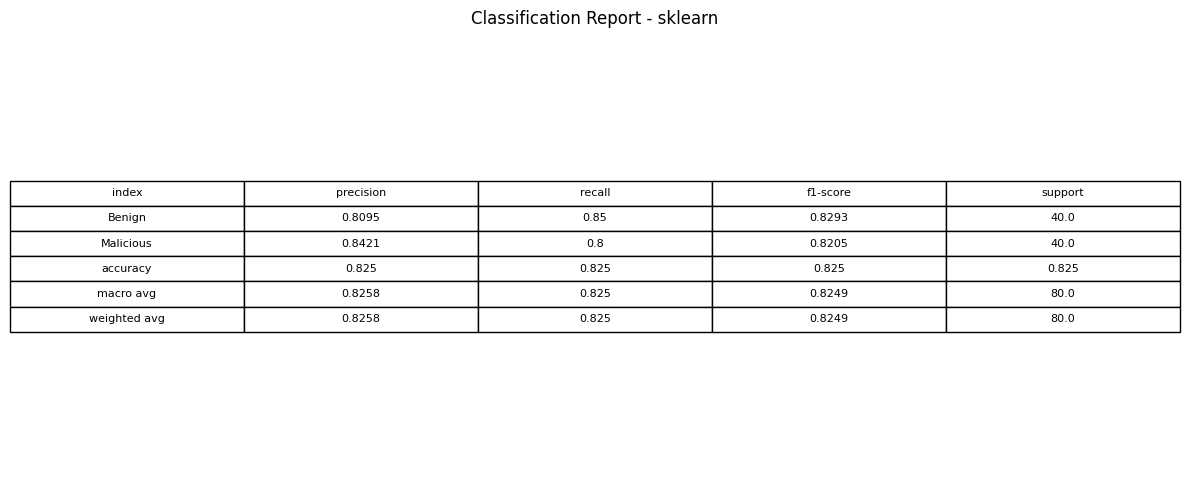

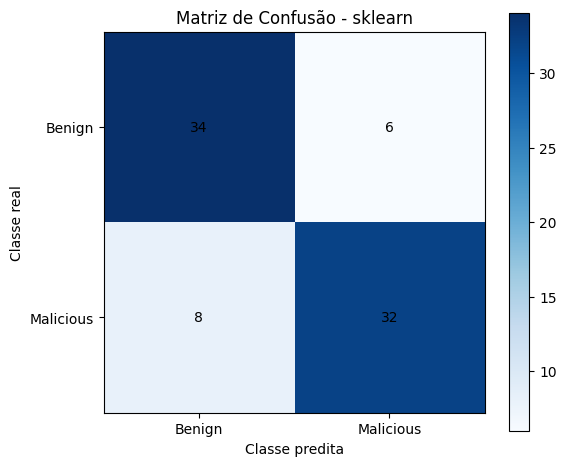


Resultados salvos em: C:\Dataset\Resultados\AutoML_Comparativo\sklearn
Pipeline carregado com sucesso.


In [28]:
# ============================================================
# EXECUÇÃO COMPLETA DO PIPELINE
# ============================================================



df_raw = carregar_csvs()
df_tratado = etapa_tratar_dataset(df_raw)
df_modelagem = etapa_criar_rotulo_binario(df_tratado)
train_data, test_data = etapa_dividir_treino_teste(df_modelagem)
resultado = executar_framework(EXECUTAR_FRAMEWORK, train_data, test_data)

print("Pipeline carregado com sucesso.")